In [62]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import time

from sklearn.mixture import GaussianMixture
from matplotlib.colors import ListedColormap
from pyjet import DTYPE_PTEPM, cluster
from tqdm import tqdm
from scipy.optimize import curve_fit

plt.rcParams.update({'font.size': 12})

## K means na dveh Gaussovih porazdelitvah (1. maloga)

- Lastna implementacija K means

In [30]:
def k_means(data, K=2, max_iter=100, tol=1e-6, random_state=42):
    """
    Lastna implementacija algoritma K-means.

    Parameters
    ----------
    data : ndarray, shape (N, d)
        Vhodne točke.
    K : int
        Število gruč.
    max_iter : int
        Največje število iteracij.
    tol : float
        Toleranca za konvergenco centroidov.
    random_state : int
        Seme generatorja naključnih števil.

    Returns
    -------
    labels : ndarray, shape (N,)
        Oznaka gruče za vsako točko.
    centroids : ndarray, shape (K, d)
        Končni centroidi.
    n_iter : int
        Število izvedenih iteracij.
    """

    rng = np.random.default_rng(random_state)

    N = len(data)

    # Začetne centroide izberemo kot K naključnih podatkovnih točk
    initial_indices = rng.choice(N, size=K, replace=False)
    centroids = data[initial_indices].copy()

    for iteration in range(max_iter):

        # Razdalja vsake točke do vsakega centroida
        # rezultat ima obliko (N, K)
        distances = np.linalg.norm(
            data[:, np.newaxis, :] - centroids[np.newaxis, :, :],
            axis=2
        )

        # Vsaki točki pripišemo najbližji centroid
        labels = np.argmin(distances, axis=1)

        new_centroids = np.zeros_like(centroids)

        for k in range(K):
            cluster_points = data[labels == k]

            # Zaščita pred prazno gručo
            if len(cluster_points) == 0:
                new_centroids[k] = data[rng.integers(N)]
            else:
                new_centroids[k] = np.mean(cluster_points, axis=0)

        # Premik centroidov med dvema iteracijama
        centroid_shift = np.linalg.norm(new_centroids - centroids)

        centroids = new_centroids

        if centroid_shift < tol:
            break

    return labels, centroids, iteration + 1

In [31]:
gauss_data = (
    "/home/tadej/Desktop/STUDIJ/mag-2.letnik/"
    "PSUF/PSUF6/data/gauss.npy"
)

data = np.load(gauss_data)

labels_kmeans, centroids, n_iter = k_means(
    data,
    K=2,
    random_state=42
)

print("Število iteracij:", n_iter)
print("Centroidi:")
print(centroids)

Število iteracij: 4
Centroidi:
[[-1.45467308 -0.49259767]
 [ 1.49244299  0.79561583]]


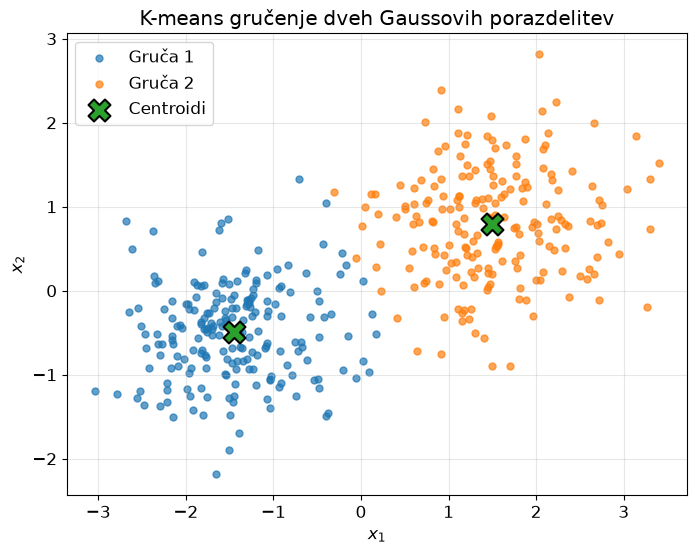

In [32]:
plt.figure(figsize=(8, 6))

for k in range(2):
    cluster_points = data[labels_kmeans == k]

    plt.scatter(
        cluster_points[:, 0],
        cluster_points[:, 1],
        s=25,
        alpha=0.7,
        label=f"Gruča {k + 1}"
    )

plt.scatter(
    centroids[:, 0],
    centroids[:, 1],
    marker="X",
    s=250,
    edgecolors="black",
    linewidths=1.5,
    label="Centroidi"
)

plt.xlabel(r"$x_1$")
plt.ylabel(r"$x_2$")
plt.title("K-means gručenje dveh Gaussovih porazdelitev")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [33]:
for k in range(2):
    cluster_points = data[labels_kmeans == k]

    mean = np.mean(cluster_points, axis=0)
    std = np.std(cluster_points, axis=0, ddof=1)

    print(f"\nGruča {k + 1}")
    print(f"Število točk: {len(cluster_points)}")
    print(f"Povprečje: mu_x = {mean[0]:.4f}, mu_y = {mean[1]:.4f}")
    print(f"Std. odklon: sigma_x = {std[0]:.4f}, sigma_y = {std[1]:.4f}")


Gruča 1
Število točk: 203
Povprečje: mu_x = -1.4547, mu_y = -0.4926
Std. odklon: sigma_x = 0.6472, sigma_y = 0.5711

Gruča 2
Število točk: 197
Povprečje: mu_x = 1.4924, mu_y = 0.7956
Std. odklon: sigma_x = 0.7283, sigma_y = 0.6703


- Implementacija GMM

In [34]:
gmm = GaussianMixture(
    n_components=2,
    covariance_type="full",
    random_state=42
)

gmm.fit(data)

labels_gmm = gmm.predict(data)

gmm_means = gmm.means_
gmm_covariances = gmm.covariances_

gmm_stds = np.sqrt(
    np.diagonal(gmm_covariances, axis1=1, axis2=2)
)

order = np.argsort(gmm_means[:, 0])

gmm_means = gmm_means[order]
gmm_stds = gmm_stds[order]
gmm_covariances = gmm_covariances[order]

for k in range(2):
    print(f"GMM, Gaussova porazdelitev {k + 1}:")
    print(
        f"  mu_x = {gmm_means[k, 0]:.4f}, "
        f"mu_y = {gmm_means[k, 1]:.4f}"
    )
    print(
        f"  sigma_x = {gmm_stds[k, 0]:.4f}, "
        f"sigma_y = {gmm_stds[k, 1]:.4f}"
    )

GMM, Gaussova porazdelitev 1:
  mu_x = -1.4992, mu_y = -0.5195
  sigma_x = 0.6126, sigma_y = 0.5476
GMM, Gaussova porazdelitev 2:
  mu_x = 1.4281, mu_y = 0.7746
  sigma_x = 0.7883, sigma_y = 0.6774


- Skupna primerjava

In [35]:
kmeans_means = np.zeros((2, 2))
kmeans_stds = np.zeros((2, 2))
kmeans_counts = np.zeros(2, dtype=int)

for k in range(2):
    cluster_points = data[labels_kmeans == k]

    kmeans_means[k] = np.mean(cluster_points, axis=0)
    kmeans_stds[k] = np.std(cluster_points, axis=0, ddof=1)
    kmeans_counts[k] = len(cluster_points)


# Gruči uredimo glede na x-koordinato centroida:
# prva bo leva, druga desna Gaussova porazdelitev.
order_kmeans = np.argsort(kmeans_means[:, 0])

kmeans_means = kmeans_means[order_kmeans]
kmeans_stds = kmeans_stds[order_kmeans]
kmeans_counts = kmeans_counts[order_kmeans]


# ============================================================
# 2. Gaussian Mixture Model
# ============================================================

gmm = GaussianMixture(
    n_components=2,
    covariance_type="full",
    random_state=42
)

gmm.fit(data)

labels_gmm = gmm.predict(data)

gmm_means = gmm.means_

# Diagonalni elementi kovariančne matrike so variance
gmm_stds = np.sqrt(
    np.diagonal(
        gmm.covariances_,
        axis1=1,
        axis2=2
    )
)

gmm_counts = np.bincount(labels_gmm, minlength=2)


# Tudi komponenti GMM uredimo glede na x-koordinato povprečja
order_gmm = np.argsort(gmm_means[:, 0])

gmm_means = gmm_means[order_gmm]
gmm_stds = gmm_stds[order_gmm]
gmm_counts = gmm_counts[order_gmm]


# ============================================================
# 3. Skupna tabela
# ============================================================

comparison = pd.DataFrame({
    "Metoda": [
        "K-means",
        "GMM",
        "K-means",
        "GMM"
    ],
    "Porazdelitev": [
        "Gauss 1",
        "Gauss 1",
        "Gauss 2",
        "Gauss 2"
    ],
    "N": [
        kmeans_counts[0],
        gmm_counts[0],
        kmeans_counts[1],
        gmm_counts[1]
    ],
    "mu_x": [
        kmeans_means[0, 0],
        gmm_means[0, 0],
        kmeans_means[1, 0],
        gmm_means[1, 0]
    ],
    "mu_y": [
        kmeans_means[0, 1],
        gmm_means[0, 1],
        kmeans_means[1, 1],
        gmm_means[1, 1]
    ],
    "sigma_x": [
        kmeans_stds[0, 0],
        gmm_stds[0, 0],
        kmeans_stds[1, 0],
        gmm_stds[1, 0]
    ],
    "sigma_y": [
        kmeans_stds[0, 1],
        gmm_stds[0, 1],
        kmeans_stds[1, 1],
        gmm_stds[1, 1]
    ]
})

print(comparison.round(4))

    Metoda Porazdelitev    N    mu_x    mu_y  sigma_x  sigma_y
0  K-means      Gauss 1  203 -1.4547 -0.4926   0.6472   0.5711
1      GMM      Gauss 1  194 -1.4992 -0.5195   0.6126   0.5476
2  K-means      Gauss 2  197  1.4924  0.7956   0.7283   0.6703
3      GMM      Gauss 2  206  1.4281  0.7746   0.7883   0.6774


## K means na hadronskih curkih (2. naloga)

In [36]:
h_bb_data = (
    "/home/tadej/Desktop/STUDIJ/mag-2.letnik/"
    "PSUF/PSUF6/data/h_bb_sorted.npy"
)

data = np.load(h_bb_data, allow_pickle=True)

print("Oblika podatkov:", data.shape)
print(len(data[0]))  # Prvih 5 točk za pregled

Oblika podatkov: (10000,)
239


In [37]:
event = np.asarray(data[0], dtype=float)

print("Oblika prvega dogodka:", event.shape)
print("Prvi delec:", event[0])

pT = event[:, 0]
eta = event[:, 1]
phi = event[:, 2]

# Masa delcev za zdaj ni pomembna
mass = event[:, 3]

# Podatki, na katerih izvajamo K-means
X = np.column_stack((eta, phi))

print("Število delcev v prvem dogodku:", len(event))

Oblika prvega dogodka: (239, 4)
Prvi delec: [ 1.95335     0.371727   -2.72236065  0.49368   ]
Število delcev v prvem dogodku: 239


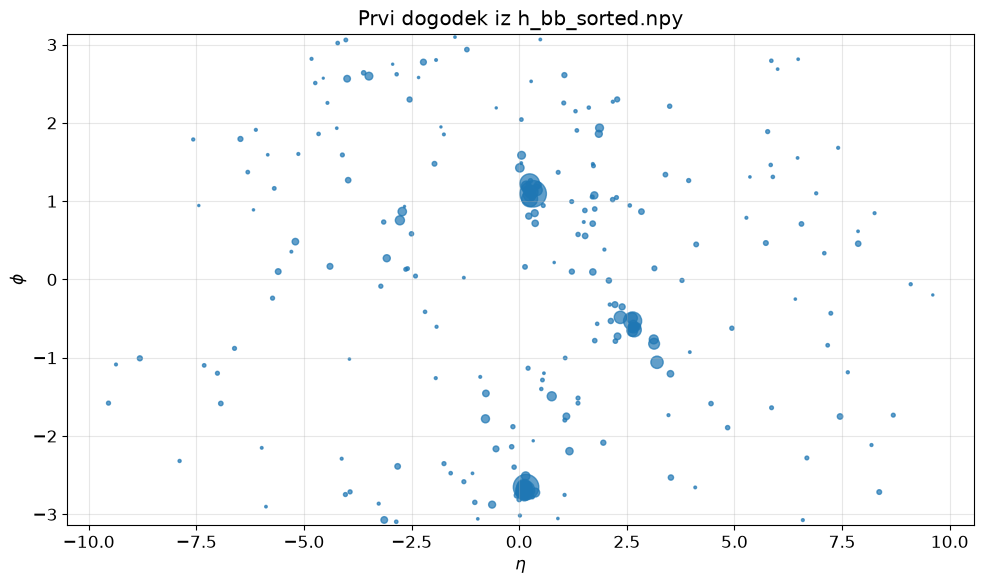

In [38]:
plt.figure(figsize=(10, 6))

plt.scatter(
    eta,
    phi,
    s= 2 + 20 * pT,
    alpha=0.7
)

plt.xlabel(r"$\eta$")
plt.ylabel(r"$\phi$")
plt.title("Prvi dogodek iz h_bb_sorted.npy")
plt.ylim(-np.pi, np.pi)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [39]:
def delta_phi(phi1, phi2):
    """
    Predznačena najkrajša kotna razlika v intervalu [-pi, pi).
    """
    return (phi1 - phi2 + np.pi) % (2 * np.pi) - np.pi


def circular_mean(phi):
    """
    Krožno povprečje kotov phi.
    """
    return np.arctan2(
        np.mean(np.sin(phi)),
        np.mean(np.cos(phi))
    )


def k_means_cylindrical(
    eta,
    phi,
    K,
    max_iter=200,
    tol=1e-6,
    random_state=None
):
    """
    K-means v prostoru R x S^1:
    eta je neperiodična, phi pa periodična koordinata.

    Parameters
    ----------
    eta, phi : ndarray, shape (N,)
        Koordinate delcev.
    K : int
        Število gruč.
    max_iter : int
        Največje število iteracij.
    tol : float
        Toleranca za konvergenco centroidov.
    random_state : int ali None
        Naključno seme.

    Returns
    -------
    labels : ndarray, shape (N,)
        Oznake gruč.
    centroids : ndarray, shape (K, 2)
        Centroidi v obliki (eta, phi).
    n_iter : int
        Število iteracij.
    inertia : float
        Vsota kvadratov razdalj do pripadajočih centroidov.
    """

    eta = np.asarray(eta, dtype=float)
    phi = np.asarray(phi, dtype=float)

    if eta.shape != phi.shape:
        raise ValueError("eta in phi morata imeti enako obliko.")

    if K < 1 or K > len(eta):
        raise ValueError("K mora biti med 1 in številom delcev.")

    rng = np.random.default_rng(random_state)

    # Začetne centroide izberemo izmed obstoječih delcev
    initial_indices = rng.choice(len(eta), size=K, replace=False)

    centroids = np.column_stack((
        eta[initial_indices],
        phi[initial_indices]
    ))

    for iteration in range(max_iter):

        # Razlika eta: oblika (N, K)
        deta = eta[:, None] - centroids[None, :, 0]

        # Periodična razlika phi: oblika (N, K)
        dphi = delta_phi(
            phi[:, None],
            centroids[None, :, 1]
        )

        distances_squared = deta**2 + dphi**2

        # Najbližji centroid
        labels = np.argmin(distances_squared, axis=1)

        new_centroids = np.empty_like(centroids)

        for k in range(K):
            mask = labels == k

            if not np.any(mask):
                # Prazno gručo ponovno inicializiramo
                index = rng.integers(len(eta))
                new_centroids[k] = [eta[index], phi[index]]

            else:
                new_centroids[k, 0] = np.mean(eta[mask])
                new_centroids[k, 1] = circular_mean(phi[mask])

        # Premiki centroidov
        shift_eta = new_centroids[:, 0] - centroids[:, 0]
        shift_phi = delta_phi(
            new_centroids[:, 1],
            centroids[:, 1]
        )

        shifts = np.sqrt(shift_eta**2 + shift_phi**2)

        centroids = new_centroids

        if np.max(shifts) < tol:
            break

    # Končne oznake
    deta = eta[:, None] - centroids[None, :, 0]
    dphi = delta_phi(
        phi[:, None],
        centroids[None, :, 1]
    )

    distances_squared = deta**2 + dphi**2
    labels = np.argmin(distances_squared, axis=1)

    inertia = np.sum(
        distances_squared[np.arange(len(eta)), labels]
    )

    return labels, centroids, iteration + 1, inertia


def jet_four_vector(event, mask):
    """
    Sešteje četverce gibalnih količin delcev v izbrani gruči.

    Vrne:
        [E, px, py, pz]
    """

    particles = event[mask]

    if len(particles) == 0:
        raise ValueError("Gruča ne vsebuje delcev.")

    pT = particles[:, 0]
    eta = particles[:, 1]
    phi = particles[:, 2]

    px = pT * np.cos(phi)
    py = pT * np.sin(phi)
    pz = pT * np.sinh(eta)

    # Aproksimacija m = 0
    energy = pT * np.cosh(eta)

    return np.array([
        np.sum(energy),
        np.sum(px),
        np.sum(py),
        np.sum(pz)
    ])


def invariant_mass(p1, p2):
    """
    Invariantna masa vsote dveh četvercev.

    p = [E, px, py, pz]
    """

    p_total = p1 + p2

    E = p_total[0]
    momentum_squared = np.sum(p_total[1:]**2)

    mass_squared = E**2 - momentum_squared

    # Zaščita pred majhnimi negativnimi vrednostmi
    # zaradi numerične natančnosti
    return np.sqrt(max(mass_squared, 0.0))


def best_kmeans_cylindrical(
    eta,
    phi,
    K,
    n_init=20,
    max_iter=200,
    tol=1e-6
):
    best_result = None
    best_inertia = np.inf

    for seed in range(n_init):
        result = k_means_cylindrical(
            eta,
            phi,
            K=K,
            max_iter=max_iter,
            tol=tol,
            random_state=seed
        )

        labels, centroids, n_iter, inertia = result

        if inertia < best_inertia:
            best_inertia = inertia
            best_result = result

    return best_result

K =  4 | mH =  415.410 GeV | pT1 =  121.062 GeV | pT2 =   88.247 GeV
K =  5 | mH =  385.186 GeV | pT1 =  120.447 GeV | pT2 =   86.971 GeV
K =  6 | mH =  181.202 GeV | pT1 =   85.170 GeV | pT2 =   73.068 GeV
K =  7 | mH =  179.715 GeV | pT1 =   84.932 GeV | pT2 =   72.988 GeV
K =  8 | mH =  179.715 GeV | pT1 =   84.932 GeV | pT2 =   72.988 GeV
K =  9 | mH =  163.591 GeV | pT1 =   78.769 GeV | pT2 =   71.409 GeV
K = 10 | mH =  170.670 GeV | pT1 =   84.161 GeV | pT2 =   71.409 GeV
K = 11 | mH =  145.331 GeV | pT1 =   84.144 GeV | pT2 =   60.867 GeV
K = 12 | mH =  133.798 GeV | pT1 =   76.182 GeV | pT2 =   61.953 GeV
K = 13 | mH =  141.327 GeV | pT1 =   82.422 GeV | pT2 =   60.867 GeV
K = 14 | mH =  127.280 GeV | pT1 =   73.019 GeV | pT2 =   60.867 GeV
K = 15 | mH =  127.280 GeV | pT1 =   73.019 GeV | pT2 =   60.867 GeV
K = 16 | mH =  127.280 GeV | pT1 =   73.019 GeV | pT2 =   60.867 GeV
K = 17 | mH =  127.650 GeV | pT1 =   73.248 GeV | pT2 =   60.835 GeV
K = 18 | mH =  126.057 GeV | pT1 =

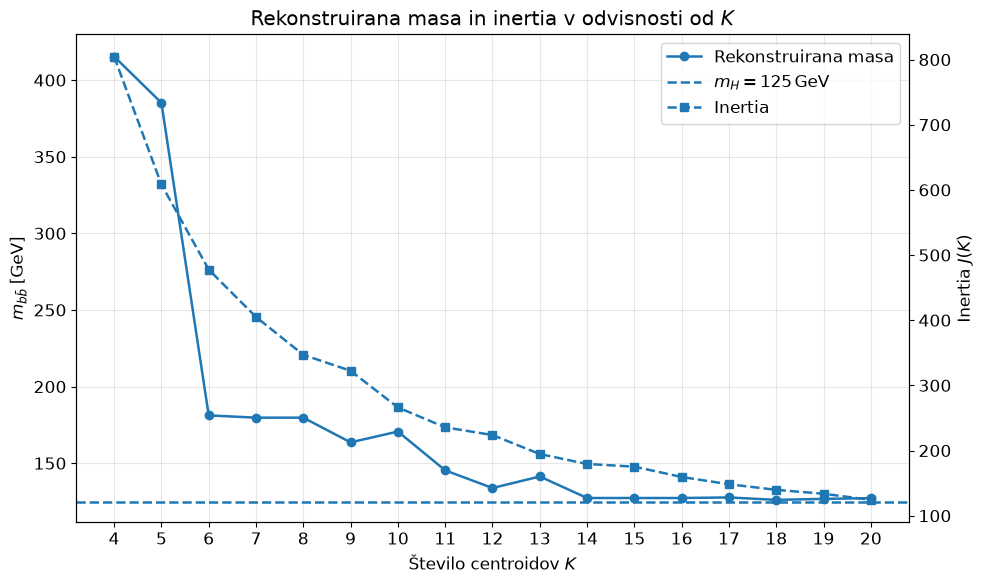

In [40]:
K_values = range(4, 21)

results = []

for K in K_values:

    labels_K, centroids_K, n_iter_K, inertia_K = (
        best_kmeans_cylindrical(
            eta,
            phi,
            K=K
        )
    )

    cluster_pT_K = np.array([
        np.sum(pT[labels_K == k])
        for k in range(K)
    ])

    leading_clusters_K = np.argsort(
        cluster_pT_K
    )[-2:][::-1]

    c1, c2 = leading_clusters_K

    p1_K = jet_four_vector(
        event,
        labels_K == c1
    )

    p2_K = jet_four_vector(
        event,
        labels_K == c2
    )

    mass_K = invariant_mass(p1_K, p2_K)

    results.append({
        "K": K,
        "mass": mass_K,
        "pT_1": cluster_pT_K[c1],
        "pT_2": cluster_pT_K[c2],
        "cluster_1": c1,
        "cluster_2": c2,
        "inertia": inertia_K,
        "iterations": n_iter_K
    })

for result in results:
    print(
        f"K = {result['K']:2d} | "
        f"mH = {result['mass']:8.3f} GeV | "
        f"pT1 = {result['pT_1']:8.3f} GeV | "
        f"pT2 = {result['pT_2']:8.3f} GeV"
    )

    K_array = np.array([
    result["K"] for result in results
])

K_array = np.array([
    result["K"] for result in results
])

mass_array = np.array([
    result["mass"] for result in results
])

inertia_array = np.array([
    result["inertia"] for result in results
])

fig, ax1 = plt.subplots(figsize=(10, 6))

# Leva y-os: invariantna masa
line1 = ax1.plot(
    K_array,
    mass_array,
    marker="o",
    linewidth=1.8,
    label="Rekonstruirana masa"
)

ax1.axhline(
    125,
    linestyle="--",
    linewidth=1.8,
    label=r"$m_H = 125\,\mathrm{GeV}$"
)

ax1.set_xlabel(r"Število centroidov $K$")
ax1.set_ylabel(r"$m_{b\bar b}\;[\mathrm{GeV}]$")
ax1.set_xticks(K_array)
ax1.grid(alpha=0.3)


# Desna y-os: inertia
ax2 = ax1.twinx()

line2 = ax2.plot(
    K_array,
    inertia_array,
    marker="s",
    linestyle="--",
    linewidth=1.8,
    label="Inertia"
)

ax2.set_ylabel(r"Inertia $J(K)$")


# Skupna legenda za obe osi
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines_1 + lines_2,
    labels_1 + labels_2,
    loc="best"
)

plt.title("Rekonstruirana masa in inertia v odvisnosti od $K$")
plt.tight_layout()
plt.show()

Dve najmočnejši gruči: 3 2
pT prve gruče:  73.019 GeV
pT druge gruče: 60.867 GeV


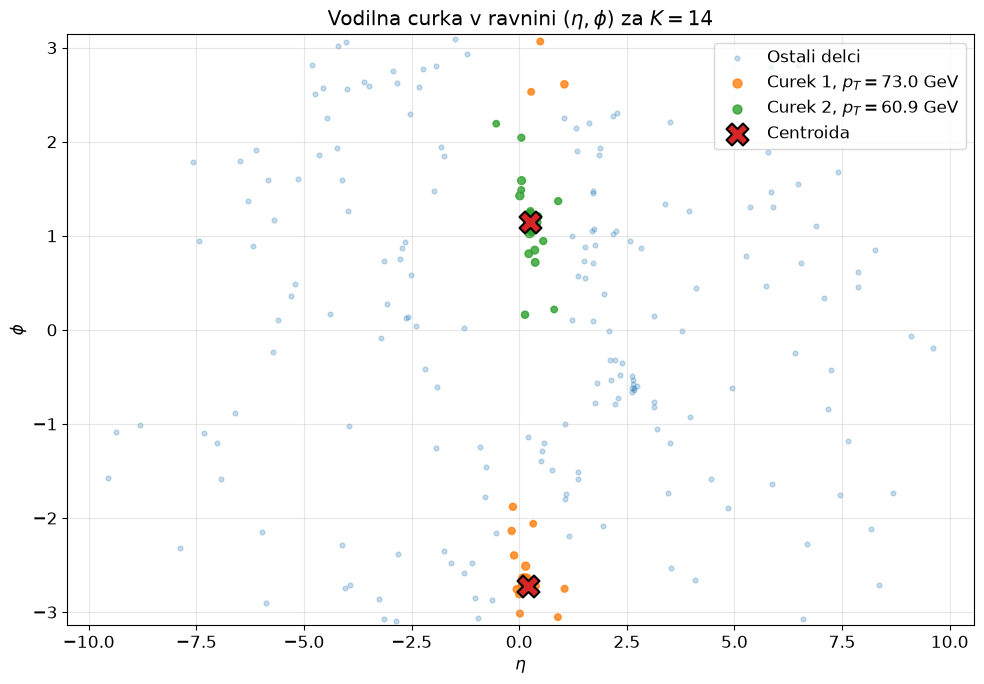

In [41]:
K = 14

# K-means za K = 14
labels_6, centroids_6, n_iter_6, inertia_6 = (
    best_kmeans_cylindrical(
        eta,
        phi,
        K=K
    )
)

# Skupni pT vsake gruče
cluster_pT_6 = np.array([
    np.sum(pT[labels_6 == k])
    for k in range(K)
])

# Indeksa dveh gruč z največjim skupnim pT
leading_clusters_6 = np.argsort(cluster_pT_6)[-2:][::-1]

c1, c2 = leading_clusters_6

print("Dve najmočnejši gruči:", c1, c2)
print(f"pT prve gruče:  {cluster_pT_6[c1]:.3f} GeV")
print(f"pT druge gruče: {cluster_pT_6[c2]:.3f} GeV")

plt.figure(figsize=(10, 7))

# Prvi vodilni curek
mask_1 = labels_6 == c1
# Drugi vodilni curek
mask_2 = labels_6 == c2
# Ostali delci (ne pripadajo nobeni od dveh gruč)
other_mask = (labels_6 != c1) & (labels_6 != c2)

# Ostali delci
plt.scatter(
    eta[other_mask],
    phi[other_mask],
    s=12,
    alpha=0.25,
    label="Ostali delci"
)

# Prvi curek
plt.scatter(
    eta[mask_1],
    phi[mask_1],
    s=20 + 10 * np.sqrt(pT[mask_1]),
    alpha=0.8,
    label=rf"Curek 1, $p_T={cluster_pT_6[c1]:.1f}$ GeV"
)

# Drugi curek
plt.scatter(
    eta[mask_2],
    phi[mask_2],
    s=20 + 10 * np.sqrt(pT[mask_2]),
    alpha=0.8,
    label=rf"Curek 2, $p_T={cluster_pT_6[c2]:.1f}$ GeV"
)

# Centroida
plt.scatter(
    centroids_6[[c1, c2], 0],
    centroids_6[[c1, c2], 1],
    marker="X",
    s=250,
    edgecolors="black",
    linewidths=1.5,
    label="Centroida",
    zorder=5
)

plt.xlabel(r"$\eta$")
plt.ylabel(r"$\phi$")
plt.title(r"Vodilna curka v ravnini $(\eta,\phi)$ za $K=14$")
plt.ylim(-np.pi, np.pi)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## Infrardeča varnost (3. naloga)

In [42]:
def reconstruct_higgs_mass(
    event,
    K=14,
    n_init=20
):
    """
    Iz dogodka rekonstruira maso Higgsovega bozona.

    Dogodek mora biti polje oblike (N, 4):
    (pT, eta, phi, m).
    """

    event = np.asarray(event, dtype=float)

    if len(event) < K:
        raise ValueError(
            "Število delcev mora biti vsaj enako K."
        )

    pT = event[:, 0]
    eta = event[:, 1]
    phi = event[:, 2]

    labels, centroids, n_iter, inertia = (
        best_kmeans_cylindrical(
            eta,
            phi,
            K=K,
            n_init=n_init
        )
    )

    # Skupni pT vsake gruče
    cluster_pT = np.array([
        np.sum(pT[labels == k])
        for k in range(K)
    ])

    # Dve gruči z največjim pT
    leading_clusters = np.argsort(
        cluster_pT
    )[-2:][::-1]

    c1, c2 = leading_clusters

    # Četverca obeh curkov
    p1 = jet_four_vector(
        event,
        labels == c1
    )

    p2 = jet_four_vector(
        event,
        labels == c2
    )

    mass = invariant_mass(p1, p2)

    return {
        "mass": mass,
        "labels": labels,
        "centroids": centroids,
        "cluster_pT": cluster_pT,
        "leading_clusters": leading_clusters,
        "inertia": inertia,
        "iterations": n_iter
    }

Začetno število delcev: 239
N =  239 | odstranjenih =    0 | odstranjeni pT =    0.000 GeV | mH =  133.759 GeV
N =  236 | odstranjenih =    3 | odstranjeni pT =    0.026 GeV | mH =  127.280 GeV
N =  234 | odstranjenih =    5 | odstranjeni pT =    0.062 GeV | mH =  128.619 GeV
N =  232 | odstranjenih =    7 | odstranjeni pT =    0.101 GeV | mH =  133.607 GeV
N =  229 | odstranjenih =   10 | odstranjeni pT =    0.178 GeV | mH =  137.318 GeV
N =  227 | odstranjenih =   12 | odstranjeni pT =    0.242 GeV | mH =  141.201 GeV
N =  225 | odstranjenih =   14 | odstranjeni pT =    0.329 GeV | mH =  128.223 GeV
N =  223 | odstranjenih =   16 | odstranjeni pT =    0.429 GeV | mH =  128.890 GeV
N =  220 | odstranjenih =   19 | odstranjeni pT =    0.592 GeV | mH =  132.489 GeV
N =  218 | odstranjenih =   21 | odstranjeni pT =    0.705 GeV | mH =  141.154 GeV
N =  216 | odstranjenih =   23 | odstranjeni pT =    0.824 GeV | mH =  141.154 GeV
N =  214 | odstranjenih =   25 | odstranjeni pT =    0.951 

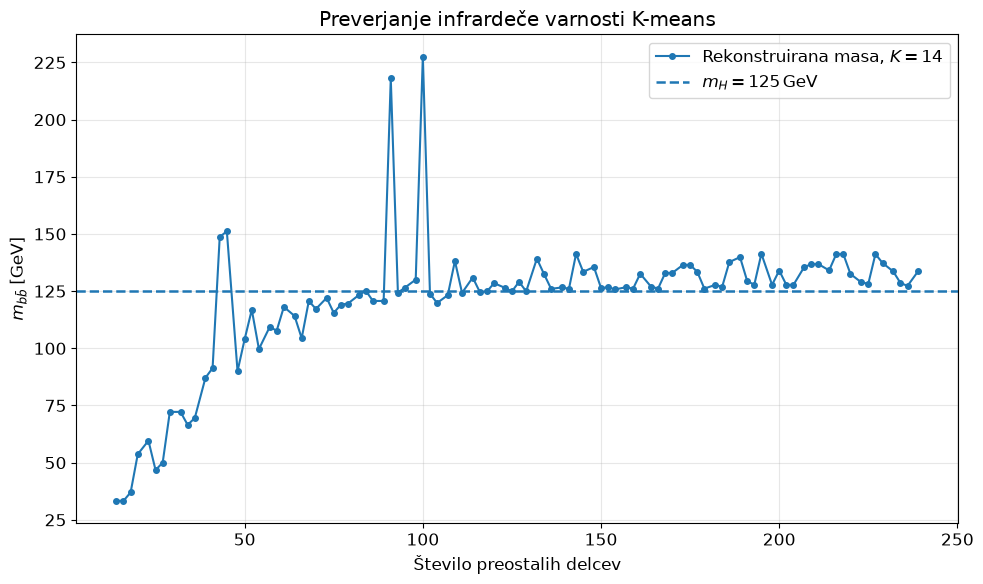

In [43]:
K = 14

event_full = np.asarray(data[0], dtype=float)

# Delce uredimo od največjega do najmanjšega pT.
# Tako lahko enostavno obdržimo prvih N najtrših delcev.
order = np.argsort(event_full[:, 0])[::-1]
event_sorted = event_full[order]

N_total = len(event_sorted)

print("Začetno število delcev:", N_total)

particle_counts = np.arange(N_total, K - 1, -1)

particle_counts = np.unique(
    np.linspace(
        K,
        N_total,
        100,
        dtype=int
    )
)[::-1]

ir_results = []

for N_particles in particle_counts:

    # Obdržimo N delcev z največjim pT.
    # S tem smo odstranili delce z najmanjšim pT.
    reduced_event = event_sorted[:N_particles]

    result = reconstruct_higgs_mass(
        reduced_event,
        K=K,
        n_init=20
    )

    removed_particles = N_total - N_particles

    removed_pT = np.sum(
        event_sorted[N_particles:, 0]
    )

    ir_results.append({
        "N_particles": N_particles,
        "N_removed": removed_particles,
        "removed_pT": removed_pT,
        "mass": result["mass"],
        "inertia": result["inertia"]
    })

for result in ir_results:
    print(
        f"N = {result['N_particles']:4d} | "
        f"odstranjenih = {result['N_removed']:4d} | "
        f"odstranjeni pT = {result['removed_pT']:8.3f} GeV | "
        f"mH = {result['mass']:8.3f} GeV"
    )

N_array = np.array([
    result["N_particles"]
    for result in ir_results
])

mass_array_ir = np.array([
    result["mass"]
    for result in ir_results
])

plt.figure(figsize=(10, 6))

plt.plot(
    N_array[::-1],
    mass_array_ir[::-1],
    marker="o",
    markersize=4,
    linewidth=1.5,
    label=rf"Rekonstruirana masa, $K={K}$"
)

plt.axhline(
    125,
    linestyle="--",
    linewidth=1.8,
    label=r"$m_H=125\,\mathrm{GeV}$"
)

plt.xlabel("Število preostalih delcev")
plt.ylabel(r"$m_{b\bar b}\;[\mathrm{GeV}]$")
plt.title("Preverjanje infrardeče varnosti K-means")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## Algoritem hierarhičnega gručenja (4. naloga)

In [44]:
def weighted_circular_mean(phi1, phi2, weight1, weight2):
    """
    pT-uteženo krožno povprečje dveh kotov.
    """
    x = weight1 * np.cos(phi1) + weight2 * np.cos(phi2)
    y = weight1 * np.sin(phi1) + weight2 * np.sin(phi2)

    return np.arctan2(y, x)


def merge_protojets(jet_i, jet_j):
    """
    Združi dva protocurka v nov protocurek.
    """

    pT_i = jet_i["pT"]
    pT_j = jet_j["pT"]

    pT_new = pT_i + pT_j

    eta_new = (
        pT_i * jet_i["eta"]
        + pT_j * jet_j["eta"]
    ) / pT_new

    phi_new = weighted_circular_mean(
        jet_i["phi"],
        jet_j["phi"],
        pT_i,
        pT_j
    )

    return {
        "pT": pT_new,
        "eta": eta_new,
        "phi": phi_new,
        "constituents": (
            jet_i["constituents"]
            + jet_j["constituents"]
        )
    }


def hierarchical_clustering(event, p=1, R=0.6):
    """
    Zaporedni hierarhični algoritem za gručenje hadronskih curkov.

    Parameters
    ----------
    event : ndarray, shape (N, 4)
        Delci v obliki (pT, eta, phi, m).

    p : {-1, 0, 1}
        p = -1  -> anti-kt
        p =  0  -> Cambridge-Aachen
        p =  1  -> kt

    R : float
        Parameter radija curka.

    Returns
    -------
    final_jets : list of dict
        Seznam končnih curkov, urejenih po padajočem pT.
    """

    event = np.asarray(event, dtype=float)

    if event.ndim != 2 or event.shape[1] != 4:
        raise ValueError(
            "Dogodek mora imeti obliko (N, 4): "
            "(pT, eta, phi, m)."
        )

    if p not in (-1, 0, 1):
        raise ValueError("Parameter p mora biti -1, 0 ali 1.")

    if R <= 0:
        raise ValueError("Parameter R mora biti pozitiven.")

    if np.any(event[:, 0] <= 0):
        raise ValueError(
            "Vsi delci morajo imeti pozitiven pT."
        )

    # ---------------------------------------------------------
    # Na začetku vsak delec predstavlja svoj protocurek
    # ---------------------------------------------------------

    protojets = []

    for i, particle in enumerate(event):
        pT_i, eta_i, phi_i, _ = particle

        protojets.append({
            "pT": pT_i,
            "eta": eta_i,
            "phi": phi_i,
            "constituents": [i]
        })

    # Seznam pravih oziroma končnih curkov
    final_jets = []

    # ---------------------------------------------------------
    # Glavna zanka
    # ---------------------------------------------------------

    while len(protojets) > 0:

        N = len(protojets)

        pT_values = np.array([
            jet["pT"] for jet in protojets
        ])

        eta_values = np.array([
            jet["eta"] for jet in protojets
        ])

        phi_values = np.array([
            jet["phi"] for jet in protojets
        ])

        # d_i = pT_i^(2p)
        beam_distances = pT_values ** (2 * p)

        # -----------------------------------------------------
        # Primer z enim samim preostalim protocurkom
        # -----------------------------------------------------

        if N == 1:
            final_jets.append(protojets.pop())
            continue

        # -----------------------------------------------------
        # Vse parske razdalje d_ij
        # -----------------------------------------------------

        delta_eta = (
            eta_values[:, None]
            - eta_values[None, :]
        )

        delta_phi_matrix = delta_phi(
            phi_values[:, None],
            phi_values[None, :]
        )

        delta_R_squared = (
            delta_eta**2
            + delta_phi_matrix**2
        )

        pT_factor = np.minimum(
            beam_distances[:, None],
            beam_distances[None, :]
        )

        pair_distances = (
            pT_factor
            * delta_R_squared
            / R**2
        )

        # Diagonala predstavlja razdaljo curka do samega sebe,
        # zato jo izločimo.
        np.fill_diagonal(pair_distances, np.inf)

        # Zaradi simetrije potrebujemo samo zgornji trikotnik.
        pair_distances[
            np.tril_indices(N, k=-1)
        ] = np.inf

        # -----------------------------------------------------
        # Najmanjši d_i
        # -----------------------------------------------------

        i_beam = np.argmin(beam_distances)
        minimum_beam_distance = beam_distances[i_beam]

        # -----------------------------------------------------
        # Najmanjši d_ij
        # -----------------------------------------------------

        flat_pair_index = np.argmin(pair_distances)

        i_pair, j_pair = np.unravel_index(
            flat_pair_index,
            pair_distances.shape
        )

        minimum_pair_distance = pair_distances[
            i_pair,
            j_pair
        ]

        # -----------------------------------------------------
        # Odločitev: združevanje ali zaključitev curka
        # -----------------------------------------------------

        if minimum_pair_distance < minimum_beam_distance:

            # Najmanjša razdalja je d_ij:
            # združimo protocurka i in j.
            new_jet = merge_protojets(
                protojets[i_pair],
                protojets[j_pair]
            )

            # Najprej odstranimo večji indeks,
            # da se manjši indeks ne spremeni.
            protojets.pop(j_pair)
            protojets.pop(i_pair)

            protojets.append(new_jet)

        else:

            # Najmanjša razdalja je d_i:
            # protocurek postane končni curek.
            final_jet = protojets.pop(i_beam)
            final_jets.append(final_jet)

    # Končne curke uredimo po padajočem pT
    final_jets.sort(
        key=lambda jet: jet["pT"],
        reverse=True
    )

    return final_jets


def hierarchical_jet_four_vector(event, jet):
    """
    Izračuna četverec curka iz njegovih originalnih delcev.

    Vrne [E, px, py, pz].
    """

    indices = jet["constituents"]
    particles = np.asarray(event[indices], dtype=float)

    pT = particles[:, 0]
    eta = particles[:, 1]
    phi = particles[:, 2]

    px = pT * np.cos(phi)
    py = pT * np.sin(phi)
    pz = pT * np.sinh(eta)

    # Aproksimacija brezmasnih delcev
    E = pT * np.cosh(eta)

    return np.array([
        np.sum(E),
        np.sum(px),
        np.sum(py),
        np.sum(pz)
    ])

def invariant_mass(p1, p2):
    p_total = p1 + p2

    E_total = p_total[0]
    momentum_squared = np.sum(p_total[1:]**2)

    mass_squared = E_total**2 - momentum_squared

    return np.sqrt(max(mass_squared, 0.0))

In [45]:
event = np.asarray(data[0], dtype=float)

print("Število delcev:", len(event))

jets = hierarchical_clustering(
    event,
    p=1,
    R=0.6
)

print("Število končnih curkov:", len(jets))

for i, jet in enumerate(jets[:10]):
    print(
        f"Curek {i + 1:2d}: "
        f"pT = {jet['pT']:9.3f} GeV, "
        f"eta = {jet['eta']:8.3f}, "
        f"phi = {jet['phi']:8.3f}, "
        f"N = {len(jet['constituents']):4d}"
    )

jet1 = jets[0]
jet2 = jets[1]

p1 = hierarchical_jet_four_vector(event, jet1)
p2 = hierarchical_jet_four_vector(event, jet2)

m_higgs = invariant_mass(p1, p2)

print(f"Število curkov: {len(jets)}")
print(f"pT prvega curka:  {jet1['pT']:.3f} GeV")
print(f"pT drugega curka: {jet2['pT']:.3f} GeV")
print(f"Rekonstruirana masa: {m_higgs:.3f} GeV")

Število delcev: 239
Število končnih curkov: 75
Curek  1: pT =    71.550 GeV, eta =    0.138, phi =   -2.678, N =   24
Curek  2: pT =    60.445 GeV, eta =    0.275, phi =    1.133, N =   23
Curek  3: pT =    34.758 GeV, eta =    2.557, phi =   -0.567, N =   17
Curek  4: pT =     9.888 GeV, eta =    3.206, phi =   -0.950, N =    6
Curek  5: pT =     5.306 GeV, eta =    1.694, phi =    0.912, N =   13
Curek  6: pT =     4.504 GeV, eta =   -2.757, phi =    0.783, N =    5
Curek  7: pT =     3.880 GeV, eta =    1.864, phi =    1.992, N =    7
Curek  8: pT =     3.313 GeV, eta =   -3.745, phi =    2.650, N =    5
Curek  9: pT =     3.109 GeV, eta =    1.170, phi =   -1.898, N =    5
Curek 10: pT =     2.997 GeV, eta =    0.691, phi =   -1.395, N =    6
Število curkov: 75
pT prvega curka:  71.550 GeV
pT drugega curka: 60.445 GeV
Rekonstruirana masa: 125.022 GeV


In [46]:
algorithm_names = {
    -1: r"anti-$k_t$",
     0: "Cambridge–Aachen",
     1: r"$k_t$"
}

R = 0.6

results_hierarchical = []

for p in [-1, 0, 1]:

    jets = hierarchical_clustering(
        event,
        p=p,
        R=R
    )

    if len(jets) < 2:
        print(
            f"Za p={p} sta nastala manj kot dva curka."
        )
        continue

    jet1 = jets[0]
    jet2 = jets[1]

    p1 = hierarchical_jet_four_vector(event, jet1)
    p2 = hierarchical_jet_four_vector(event, jet2)

    mass = invariant_mass(p1, p2)

    results_hierarchical.append({
        "p": p,
        "algorithm": algorithm_names[p],
        "R": R,
        "N_jets": len(jets),
        "pT_1": jet1["pT"],
        "pT_2": jet2["pT"],
        "mass": mass
    })

    jets = hierarchical_clustering(
    event,
    p=1,
    R=0.6
)

jet1 = jets[0]
jet2 = jets[1]

p1 = hierarchical_jet_four_vector(event, jet1)
p2 = hierarchical_jet_four_vector(event, jet2)

m_higgs = invariant_mass(p1, p2)

print(f"Število curkov: {len(jets)}")
print(f"pT prvega curka:  {jet1['pT']:.3f} GeV")
print(f"pT drugega curka: {jet2['pT']:.3f} GeV")
print(f"Rekonstruirana masa: {m_higgs:.3f} GeV")

Število curkov: 75
pT prvega curka:  71.550 GeV
pT drugega curka: 60.445 GeV
Rekonstruirana masa: 125.022 GeV


- plottanje # curkov ter invariantne mase v odvisnosti od R

In [47]:
R_values = np.linspace(0.2, 2.0, 30)

p_values = [-1, 0, 1]

algorithm_names = {
    -1: r"anti-$k_t$",
     0: "Cambridge–Aachen",
     1: r"$k_t$"
}

hierarchical_R_results = {
    p: {
        "R": [],
        "N_jets": [],
        "mass": [],
        "pT_1": [],
        "pT_2": []
    }
    for p in p_values
}

event = np.asarray(data[0], dtype=float)

for p in p_values:

    print(f"\nRačunam za {algorithm_names[p]} ...")

    for R in R_values:

        jets = hierarchical_clustering(
            event,
            p=p,
            R=R
        )

        N_jets = len(jets)

        # Hierarhični algoritem bi praviloma moral vrniti
        # vsaj dva curka, vendar vseeno dodamo zaščito.
        if N_jets >= 2:

            jet1 = jets[0]
            jet2 = jets[1]

            four_vector_1 = hierarchical_jet_four_vector(
                event,
                jet1
            )

            four_vector_2 = hierarchical_jet_four_vector(
                event,
                jet2
            )

            mass = invariant_mass(
                four_vector_1,
                four_vector_2
            )

            pT_1 = jet1["pT"]
            pT_2 = jet2["pT"]

        else:
            mass = np.nan
            pT_1 = np.nan
            pT_2 = np.nan

        hierarchical_R_results[p]["R"].append(R)
        hierarchical_R_results[p]["N_jets"].append(N_jets)
        hierarchical_R_results[p]["mass"].append(mass)
        hierarchical_R_results[p]["pT_1"].append(pT_1)
        hierarchical_R_results[p]["pT_2"].append(pT_2)

        print(
            f"p = {p:2d}, "
            f"R = {R:.2f}, "
            f"N_curkov = {N_jets:4d}, "
            f"mH = {mass:8.3f} GeV"
        )


Računam za anti-$k_t$ ...
p = -1, R = 0.20, N_curkov =  169, mH =  114.705 GeV
p = -1, R = 0.26, N_curkov =  155, mH =  117.030 GeV
p = -1, R = 0.32, N_curkov =  145, mH =  119.747 GeV
p = -1, R = 0.39, N_curkov =  132, mH =  120.201 GeV
p = -1, R = 0.45, N_curkov =  117, mH =  123.111 GeV
p = -1, R = 0.51, N_curkov =  104, mH =  123.111 GeV
p = -1, R = 0.57, N_curkov =   90, mH =  124.413 GeV
p = -1, R = 0.63, N_curkov =   79, mH =  124.826 GeV
p = -1, R = 0.70, N_curkov =   70, mH =  125.229 GeV
p = -1, R = 0.76, N_curkov =   66, mH =  125.229 GeV
p = -1, R = 0.82, N_curkov =   61, mH =  126.602 GeV
p = -1, R = 0.88, N_curkov =   56, mH =  128.054 GeV
p = -1, R = 0.94, N_curkov =   52, mH =  128.386 GeV
p = -1, R = 1.01, N_curkov =   51, mH =  129.423 GeV
p = -1, R = 1.07, N_curkov =   42, mH =  129.471 GeV
p = -1, R = 1.13, N_curkov =   38, mH =  129.510 GeV
p = -1, R = 1.19, N_curkov =   36, mH =  132.174 GeV
p = -1, R = 1.26, N_curkov =   31, mH =  133.005 GeV
p = -1, R = 1.32, N

In [48]:
for p in p_values:
    for key in hierarchical_R_results[p]:
        hierarchical_R_results[p][key] = np.asarray(
            hierarchical_R_results[p][key]
        )

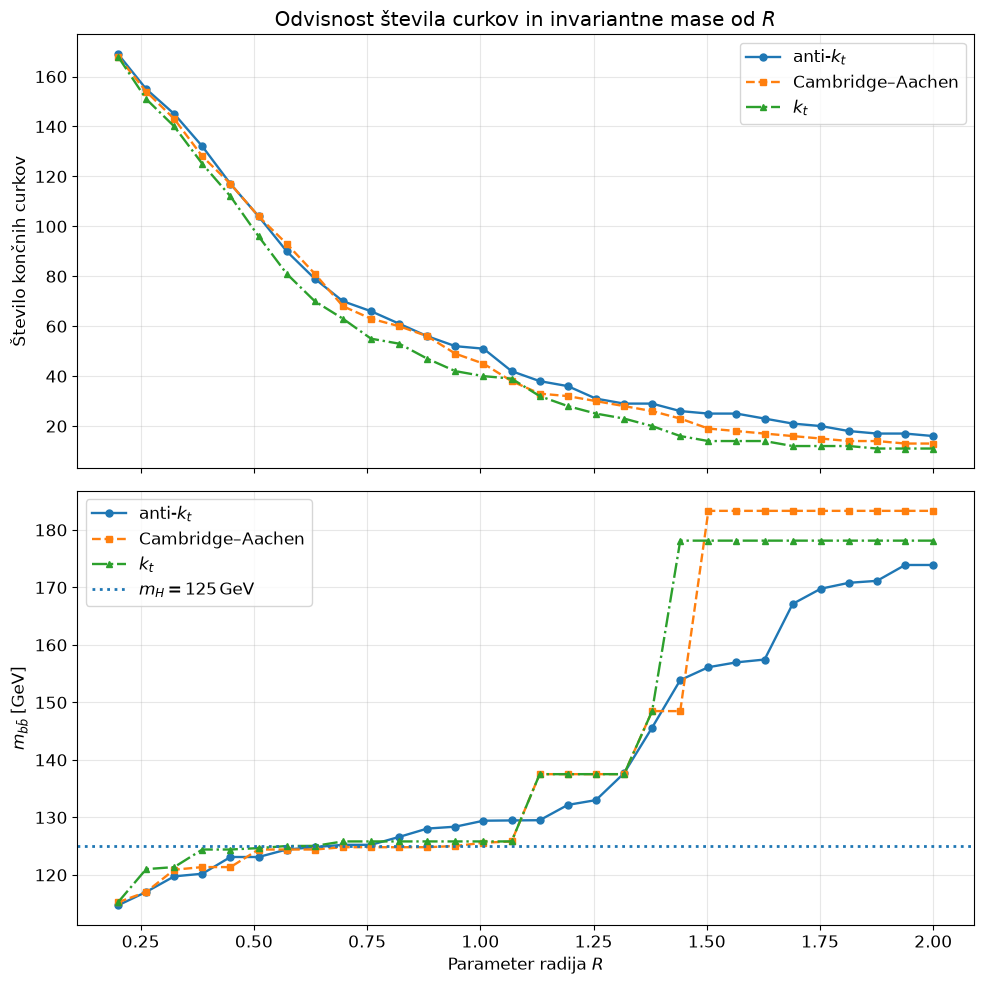

In [49]:
fig, axes = plt.subplots(
    2,
    1,
    figsize=(10, 10),
    sharex=True
)

markers = {
    -1: "o",
     0: "s",
     1: "^"
}

linestyles = {
    -1: "-",
     0: "--",
     1: "-."
}


# ============================================================
# Zgornji graf: število končnih curkov
# ============================================================

for p in p_values:

    axes[0].plot(
        hierarchical_R_results[p]["R"],
        hierarchical_R_results[p]["N_jets"],
        marker=markers[p],
        linestyle=linestyles[p],
        linewidth=1.7,
        markersize=5,
        label=algorithm_names[p]
    )

axes[0].set_ylabel("Število končnih curkov")
axes[0].set_title(
    r"Odvisnost števila curkov in invariantne mase od $R$"
)
axes[0].grid(alpha=0.3)
axes[0].legend()


# ============================================================
# Spodnji graf: invariantna masa
# ============================================================

for p in p_values:

    axes[1].plot(
        hierarchical_R_results[p]["R"],
        hierarchical_R_results[p]["mass"],
        marker=markers[p],
        linestyle=linestyles[p],
        linewidth=1.7,
        markersize=5,
        label=algorithm_names[p]
    )

axes[1].axhline(
    125,
    linestyle=":",
    linewidth=2,
    label=r"$m_H=125\,\mathrm{GeV}$"
)

axes[1].set_xlabel(r"Parameter radija $R$")
axes[1].set_ylabel(
    r"$m_{b\bar b}\;[\mathrm{GeV}]$"
)
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

In [50]:
def jet_area_labels(
    jets,
    p,
    R,
    eta_grid,
    phi_grid
):
    """
    Vsaki točki mreže (eta, phi) pripiše najbližji končni curek
    glede na generalizirano razdaljo algoritma.

    Točke, ki niso znotraj R nobene osi curka, dobijo oznako -1.
    """

    jet_eta = np.array([
        jet["eta"] for jet in jets
    ])

    jet_phi = np.array([
        jet["phi"] for jet in jets
    ])

    jet_pT = np.array([
        jet["pT"] for jet in jets
    ])

    # Mreža oblike (N_phi, N_eta)
    ETA, PHI = np.meshgrid(
        eta_grid,
        phi_grid
    )

    # Razlike do vseh osi curkov:
    # rezultat ima obliko (N_phi, N_eta, N_jets)
    delta_eta = (
        ETA[..., None]
        - jet_eta[None, None, :]
    )

    delta_phi_grid = delta_phi(
        PHI[..., None],
        jet_phi[None, None, :]
    )

    delta_R_squared = (
        delta_eta**2
        + delta_phi_grid**2
    )

    # Zelo majhen pT testnega oziroma ghost delca
    ghost_pT = 1e-8

    ghost_distance = ghost_pT ** (2 * p)
    jet_distance = jet_pT ** (2 * p)

    pair_distance = (
        np.minimum(
            ghost_distance,
            jet_distance[None, None, :]
        )
        * delta_R_squared
        / R**2
    )

    # Curek z najmanjšo generalizirano razdaljo
    labels = np.argmin(
        pair_distance,
        axis=2
    )

    # Točke zunaj R vseh osi curkov pustimo nepobarvane.
    minimum_delta_R_squared = np.min(
        delta_R_squared,
        axis=2
    )

    labels[
        minimum_delta_R_squared > R**2
    ] = -1

    return labels

anti-$k_t$: 84 vseh curkov, 3 curkov s pT > 10.0 GeV
Cambridge–Aachen: 86 vseh curkov, 3 curkov s pT > 10.0 GeV
$k_t$: 75 vseh curkov, 3 curkov s pT > 10.0 GeV


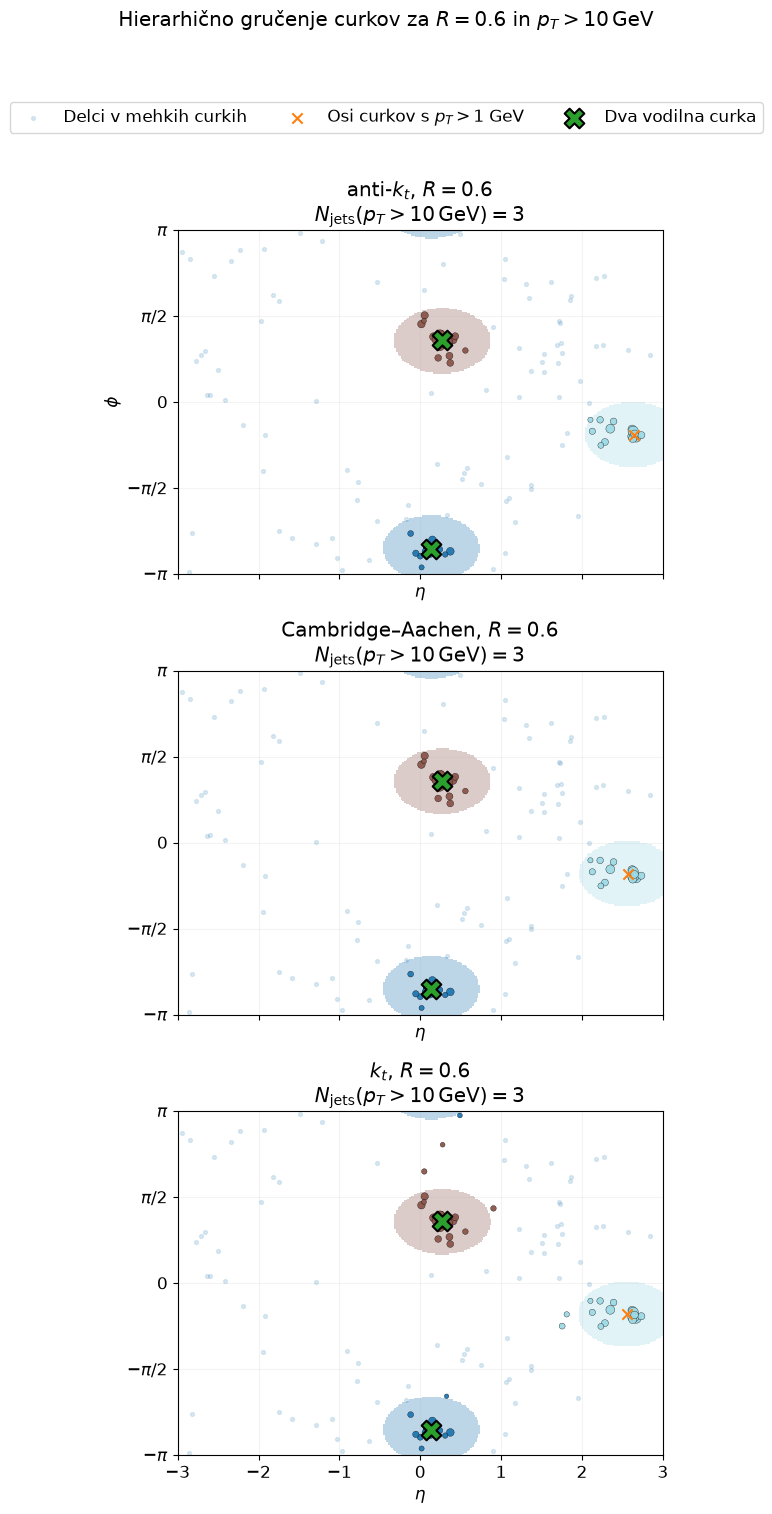

In [51]:
event = np.asarray(data[0], dtype=float)

R = 0.6
pT_min = 10.0

p_values = [-1, 0, 1]

algorithm_names = {
    -1: r"anti-$k_t$",
     0: "Cambridge–Aachen",
     1: r"$k_t$"
}

eta_min = -3.0
eta_max = 3.0

phi_min = -np.pi
phi_max = np.pi

N_eta = 300
N_phi = 240

eta_grid = np.linspace(
    eta_min,
    eta_max,
    N_eta
)

phi_grid = np.linspace(
    phi_min,
    phi_max,
    N_phi
)

fig, axes = plt.subplots(
    3,
    1,
    figsize=(6, 14),
    sharex=True,
    sharey=True
)

for ax, p in zip(axes, p_values):

    # Vsi končni curki
    jets_all = hierarchical_clustering(
        event,
        p=p,
        R=R
    )

    # Obdržimo samo curke s pT > 10 GeV
    jets = [
        jet for jet in jets_all
        if jet["pT"] > pT_min
    ]

    print(
        f"{algorithm_names[p]}: "
        f"{len(jets_all)} vseh curkov, "
        f"{len(jets)} curkov s pT > {pT_min:.1f} GeV"
    )

    if len(jets) == 0:
        ax.set_title(
            rf"{algorithm_names[p]}, $R={R}$"
            "\nNi curkov nad pragom"
        )
        continue

    # Območja samo izbranih curkov
    area_labels = jet_area_labels(
        jets=jets,
        p=p,
        R=R,
        eta_grid=eta_grid,
        phi_grid=phi_grid
    )

    base_cmap = plt.get_cmap(
        "tab20",
        max(len(jets), 1)
    )

    colors = [
        base_cmap(i)
        for i in range(max(len(jets), 1))
    ]

    cmap = ListedColormap(colors)

    masked_areas = np.ma.masked_where(
        area_labels < 0,
        area_labels
    )

    ax.imshow(
        masked_areas,
        origin="lower",
        extent=[
            eta_min,
            eta_max,
            phi_min,
            phi_max
        ],
        aspect="auto",
        interpolation="nearest",
        cmap=cmap,
        alpha=0.30
    )

    # Delci, ki pripadajo izbranim curkom
    particle_jet_labels = np.full(
        len(event),
        -1,
        dtype=int
    )

    for jet_index, jet in enumerate(jets):
        particle_jet_labels[
            jet["constituents"]
        ] = jet_index

    selected_particle_mask = (
        particle_jet_labels >= 0
    )

    particle_pT = event[:, 0]
    particle_eta = event[:, 1]
    particle_phi = event[:, 2]

    point_sizes = (
        8
        + 70 * np.sqrt(
            particle_pT / particle_pT.max()
        )
    )

    # Ostali delci v sivem ozadju
    ax.scatter(
        particle_eta[~selected_particle_mask],
        particle_phi[~selected_particle_mask],
        s=8,
        alpha=0.15,
        label="Delci v mehkih curkih",
        zorder=2
    )

    # Delci v curkih nad pragom
    ax.scatter(
        particle_eta[selected_particle_mask],
        particle_phi[selected_particle_mask],
        c=particle_jet_labels[selected_particle_mask],
        cmap=cmap,
        s=point_sizes[selected_particle_mask],
        edgecolors="black",
        linewidths=0.25,
        alpha=0.95,
        zorder=3
    )

    # Osi izbranih curkov
    jet_eta = np.array([
        jet["eta"] for jet in jets
    ])

    jet_phi = np.array([
        jet["phi"] for jet in jets
    ])

    jet_pT = np.array([
        jet["pT"] for jet in jets
    ])

    ax.scatter(
        jet_eta,
        jet_phi,
        marker="x",
        s=55,
        linewidths=1.5,
        label=r"Osi curkov s $p_T>1$ GeV",
        zorder=4
    )

    # Dva najmočnejša curka
    if len(jets) >= 2:

        leading_indices = np.argsort(
            jet_pT
        )[-2:][::-1]

        ax.scatter(
            jet_eta[leading_indices],
            jet_phi[leading_indices],
            marker="X",
            s=200,
            edgecolors="black",
            linewidths=1.5,
            label="Dva vodilna curka",
            zorder=5
        )

    ax.set_title(
        rf"{algorithm_names[p]}, $R={R}$"
        "\n"
        rf"$N_{{\mathrm{{jets}}}}(p_T>{pT_min:.0f}\,\mathrm{{GeV}})"
        rf"={len(jets)}$"
    )

    ax.set_xlabel(r"$\eta$")
    ax.set_xlim(eta_min, eta_max)
    ax.set_ylim(phi_min, phi_max)

    ax.set_yticks([
        -np.pi,
        -np.pi / 2,
        0,
        np.pi / 2,
        np.pi
    ])

    ax.set_yticklabels([
        r"$-\pi$",
        r"$-\pi/2$",
        r"$0$",
        r"$\pi/2$",
        r"$\pi$"
    ])

    ax.grid(alpha=0.15)

axes[0].set_ylabel(r"$\phi$")

handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=3,
    bbox_to_anchor=(0.5, 1.02)
)

fig.suptitle(
    rf"Hierarhično gručenje curkov za $R={R}$ "
    rf"in $p_T>{pT_min:.0f}\,\mathrm{{GeV}}$",
    y=1.08
)

plt.tight_layout()
plt.show()

## Infrardeča varnost ter čas izvajanja (5. in 6. naloga)

In [52]:
event_full = np.asarray(data[0], dtype=float)

# Delce uredimo po padajočem pT.
# Tako event_sorted[:N] vsebuje N najtrših delcev.
order = np.argsort(event_full[:, 0])[::-1]
event_sorted = event_full[order]

N_total = len(event_sorted)

print("Število delcev v dogodku:", N_total)

Število delcev v dogodku: 239


In [53]:
def mass_custom_algorithm(event, p=1, R=0.6):
    """
    Rekonstruira Higgsovo maso z našim implementiranim
    hierarhičnim algoritmom.
    """

    event = np.asarray(event, dtype=float)

    jets = hierarchical_clustering(
        event,
        p=p,
        R=R
    )

    if len(jets) < 2:
        return np.nan

    # Curki so že urejeni po padajočem pT.
    jet1 = jets[0]
    jet2 = jets[1]

    four_vector_1 = hierarchical_jet_four_vector(
        event,
        jet1
    )

    four_vector_2 = hierarchical_jet_four_vector(
        event,
        jet2
    )

    return invariant_mass(
        four_vector_1,
        four_vector_2
    )


def mass_pyjet(event, p=1, R=0.6):
    """
    Rekonstruira Higgsovo maso z algoritmom iz knjižnice pyjet.
    """

    event = np.asarray(event, dtype=float)

    pyjet_event = np.array(
        [tuple(particle) for particle in event],
        dtype=DTYPE_PTEPM
    )

    sequence = cluster(
        pyjet_event,
        ep=False,
        R=R,
        p=p
    )

    jets = sequence.inclusive_jets()

    if len(jets) < 2:
        return np.nan

    # Za vsak primer jih izrecno uredimo po padajočem pT.
    jets = sorted(
        jets,
        key=lambda jet: jet.pt,
        reverse=True
    )

    jet1 = jets[0]
    jet2 = jets[1]

    E = jet1.e + jet2.e
    px = jet1.px + jet2.px
    py = jet1.py + jet2.py
    pz = jet1.pz + jet2.pz

    mass_squared = (
        E**2
        - px**2
        - py**2
        - pz**2
    )

    return np.sqrt(max(mass_squared, 0.0))

In [54]:
minimum_particles = 20

particle_counts = np.unique(
    np.linspace(
        minimum_particles,
        N_total,
        40,
        dtype=int
    )
)

p = 1
R = 0.6

mass_custom_values = []
mass_pyjet_values = []

time_custom_values = []
time_pyjet_values = []

for N in particle_counts:

    reduced_event = event_sorted[:N]

    # ========================================================
    # Implementirani algoritem
    # ========================================================

    start = time.perf_counter()

    mass_custom = mass_custom_algorithm(
        reduced_event,
        p=p,
        R=R
    )

    end = time.perf_counter()

    custom_time = end - start

    # ========================================================
    # Pyjet
    # ========================================================

    start = time.perf_counter()

    mass_fastjet = mass_pyjet(
        reduced_event,
        p=p,
        R=R
    )

    end = time.perf_counter()

    pyjet_time = end - start

    # ========================================================
    # Shranjevanje
    # ========================================================

    mass_custom_values.append(mass_custom)
    mass_pyjet_values.append(mass_fastjet)

    time_custom_values.append(custom_time)
    time_pyjet_values.append(pyjet_time)

    print(
        f"N = {N:4d} | "
        f"m_custom = {mass_custom:8.3f} GeV | "
        f"m_pyjet = {mass_fastjet:8.3f} GeV | "
        f"t_custom = {custom_time:10.6f} s | "
        f"t_pyjet = {pyjet_time:10.6f} s"
    )

particle_counts = np.asarray(particle_counts)

mass_custom_values = np.asarray(mass_custom_values)
mass_pyjet_values = np.asarray(mass_pyjet_values)

time_custom_values = np.asarray(time_custom_values)
time_pyjet_values = np.asarray(time_pyjet_values)

N =   20 | m_custom =   97.391 GeV | m_pyjet =   97.458 GeV | t_custom =   0.001701 s | t_pyjet =   0.000121 s
N =   25 | m_custom =  102.312 GeV | m_pyjet =  102.382 GeV | t_custom =   0.001730 s | t_pyjet =   0.000110 s
N =   31 | m_custom =  105.930 GeV | m_pyjet =  106.062 GeV | t_custom =   0.002103 s | t_pyjet =   0.000117 s
N =   36 | m_custom =  109.160 GeV | m_pyjet =  109.298 GeV | t_custom =   0.002664 s | t_pyjet =   0.000154 s
N =   42 | m_custom =  111.805 GeV | m_pyjet =  111.951 GeV | t_custom =   0.003132 s | t_pyjet =   0.000159 s
N =   48 | m_custom =  114.847 GeV | m_pyjet =  115.002 GeV | t_custom =   0.003495 s | t_pyjet =   0.000169 s
N =   53 | m_custom =  118.546 GeV | m_pyjet =  118.710 GeV | t_custom =   0.004093 s | t_pyjet =   0.000174 s
N =   59 | m_custom =  118.546 GeV | m_pyjet =  118.710 GeV | t_custom =   0.003349 s | t_pyjet =   0.000154 s
N =   64 | m_custom =  120.684 GeV | m_pyjet =  120.859 GeV | t_custom =   0.003903 s | t_pyjet =   0.000157 s
N

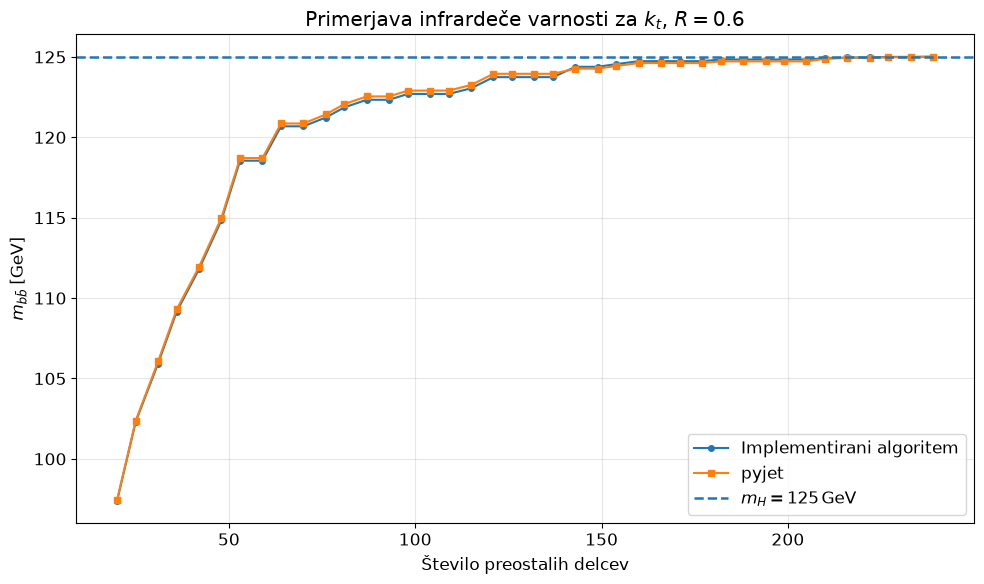

In [55]:
plt.figure(figsize=(10, 6))

plt.plot(
    particle_counts,
    mass_custom_values,
    marker="o",
    markersize=4,
    linewidth=1.5,
    label="Implementirani algoritem"
)

plt.plot(
    particle_counts,
    mass_pyjet_values,
    marker="s",
    markersize=4,
    linewidth=1.5,
    label="pyjet"
)

plt.axhline(
    125,
    linestyle="--",
    linewidth=1.8,
    label=r"$m_H=125\,\mathrm{GeV}$"
)

plt.xlabel("Število preostalih delcev")
plt.ylabel(r"$m_{b\bar b}\;[\mathrm{GeV}]$")
plt.title(
    r"Primerjava infrardeče varnosti za $k_t$, $R=0.6$"
)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

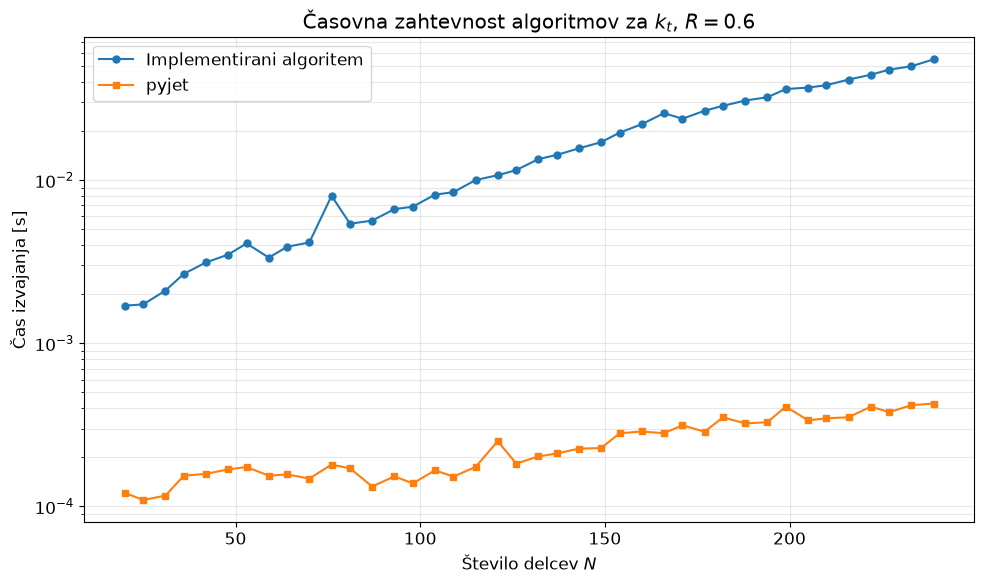

In [61]:
plt.figure(figsize=(10, 6))

plt.plot(
    particle_counts,
    time_custom_values,
    marker="o",
    markersize=5,
    linewidth=1.5,
    label="Implementirani algoritem"
)

plt.plot(
    particle_counts,
    time_pyjet_values,
    marker="s",
    markersize=5,
    linewidth=1.5,
    label="pyjet"
)

plt.yscale("log")

plt.xlabel("Število delcev $N$")
plt.ylabel("Čas izvajanja [s]")
plt.title(
    r"Časovna zahtevnost algoritmov za $k_t$, $R=0.6$"
)

plt.grid(
    which="both",
    alpha=0.3
)

plt.legend()
plt.tight_layout()
plt.show()

## Algoritem na vseh dogodkih (7. naloga)

In [66]:
h_bb_path = (
    "/home/tadej/Desktop/STUDIJ/mag-2.letnik/"
    "PSUF/PSUF6/data/h_bb_sorted.npy"
)

h_bb_data = np.load(
    h_bb_path,
    allow_pickle=True
)

print("Število dogodkov:", len(h_bb_data))
print("Prvi dogodek:", np.asarray(h_bb_data[0]).shape)

Število dogodkov: 10000
Prvi dogodek: (239, 4)


In [67]:
def reconstruct_mass_pyjet(event, p=1, R=0.6):
    """
    Rekonstruira invariantno maso dveh vodilnih curkov
    z algoritmom iz knjižnice pyjet.
    """

    event = np.asarray(event, dtype=float)

    if len(event) < 2:
        return np.nan

    # Pretvorba v strukturirano polje, ki ga zahteva pyjet
    pyjet_event = np.zeros(
        len(event),
        dtype=DTYPE_PTEPM
    )

    pyjet_event["pT"] = event[:, 0]
    pyjet_event["eta"] = event[:, 1]
    pyjet_event["phi"] = event[:, 2]
    pyjet_event["mass"] = event[:, 3]

    sequence = cluster(
        pyjet_event,
        R=R,
        p=p,
        ep=False
    )

    jets = sequence.inclusive_jets()

    if len(jets) < 2:
        return np.nan

    jets = sorted(
        jets,
        key=lambda jet: jet.pt,
        reverse=True
    )

    jet1 = jets[0]
    jet2 = jets[1]

    E_total = jet1.e + jet2.e
    px_total = jet1.px + jet2.px
    py_total = jet1.py + jet2.py
    pz_total = jet1.pz + jet2.pz

    mass_squared = (
        E_total**2
        - px_total**2
        - py_total**2
        - pz_total**2
    )

    return np.sqrt(max(mass_squared, 0.0))

In [68]:
p = 1
R = 0.6

reconstructed_masses = []

for event in tqdm(
    h_bb_data,
    desc="Gručenje dogodkov"
):
    mass = reconstruct_mass_pyjet(
        event,
        p=p,
        R=R
    )

    reconstructed_masses.append(mass)

reconstructed_masses = np.asarray(
    reconstructed_masses
)

Gručenje dogodkov: 100%|██████████| 10000/10000 [00:04<00:00, 2311.92it/s]


In [69]:
valid_mask = (
    np.isfinite(reconstructed_masses)
    & (reconstructed_masses > 0)
)

reconstructed_masses = reconstructed_masses[
    valid_mask
]

print(
    "Število uspešno rekonstruiranih dogodkov:",
    len(reconstructed_masses)
)

Število uspešno rekonstruiranih dogodkov: 10000


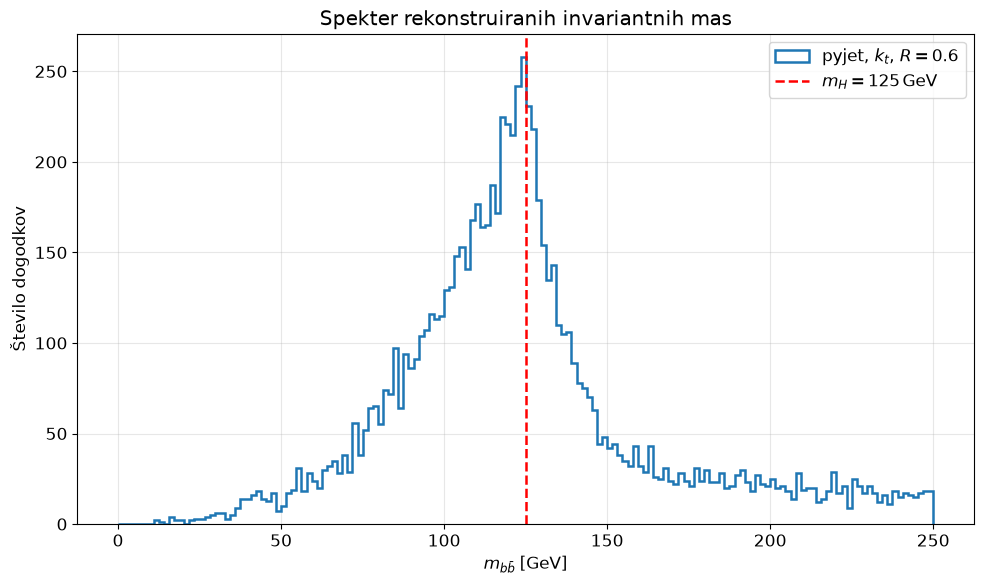

In [136]:
plt.figure(figsize=(10, 6))

counts, bin_edges, _ = plt.hist(
    reconstructed_masses,
    bins=160,
    range=(0, 250),
    histtype="step",
    linewidth=1.8,
    label=rf"pyjet, $k_t$, $R={R}$"
)

plt.axvline(
    125,
    linestyle="--",
    linewidth=1.8,
    label=r"$m_H=125\,\mathrm{GeV}$",
    c='red'
)

plt.xlabel(
    r"$m_{b\bar b}\;[\mathrm{GeV}]$"
)
plt.ylabel("Število dogodkov")
plt.title(
    "Spekter rekonstruiranih invariantnih mas"
)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [72]:
def gaussian_plus_linear(
    m,
    amplitude,
    mean,
    sigma,
    background_0,
    background_1
):
    gaussian = amplitude * np.exp(
        -0.5 * ((m - mean) / sigma)**2
    )

    background = (
        background_0
        + background_1 * m
    )

    return gaussian + background

In [77]:
fit_min = 80
fit_max = 170

hist_counts, hist_edges = np.histogram(
    reconstructed_masses,
    bins=80,
    range=(0, 250)
)

bin_centers = 0.5 * (
    hist_edges[:-1]
    + hist_edges[1:]
)

bin_widths = np.diff(hist_edges)

fit_mask = (
    (bin_centers >= fit_min)
    & (bin_centers <= fit_max)
)

x_fit = bin_centers[fit_mask]
y_fit = hist_counts[fit_mask]

y_error = np.sqrt(
    np.maximum(y_fit, 1)
)

initial_parameters = [
    np.max(y_fit),   # amplituda
    125.0,           # srednja vrednost
    15.0,            # širina
    np.min(y_fit),   # konstantno ozadje
    0.0              # naklon ozadja
]

optimal_parameters, covariance = curve_fit(
    gaussian_plus_linear,
    x_fit,
    y_fit,
    p0=initial_parameters,
    sigma=y_error,
    absolute_sigma=True,
    maxfev=20000
)

parameter_errors = np.sqrt(
    np.diag(covariance)
)

(
    amplitude_fit,
    mass_fit,
    sigma_fit,
    background_0_fit,
    background_1_fit
) = optimal_parameters

(
    amplitude_error,
    mass_error,
    sigma_error,
    background_0_error,
    background_1_error
) = parameter_errors

print(
    f"Rekonstruirana masa Higgsovega bozona:\n"
    f"m_H = ({mass_fit:.3f} ± {mass_error:.3f}) GeV"
)

print(
    f"Širina vrha:\n"
    f"sigma = ({sigma_fit:.3f} ± "
    f"{sigma_error:.3f}) GeV"
)

print(optimal_parameters)

Rekonstruirana masa Higgsovega bozona:
m_H = (120.257 ± 0.397) GeV
Širina vrha:
sigma = (12.544 ± 0.450) GeV
[313.70564607 120.25740705  12.54417841 275.76779453  -1.32399998]


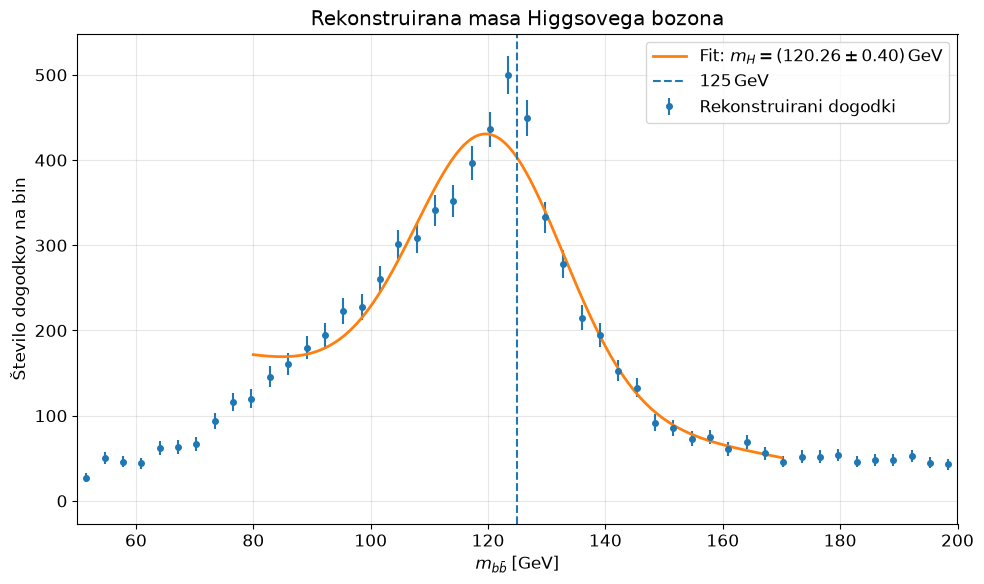

In [75]:
mass_plot = np.linspace(
    fit_min,
    fit_max,
    1000
)

fit_curve = gaussian_plus_linear(
    mass_plot,
    *optimal_parameters
)

plt.figure(figsize=(10, 6))

plt.errorbar(
    bin_centers,
    hist_counts,
    yerr=np.sqrt(
        np.maximum(hist_counts, 1)
    ),
    fmt="o",
    markersize=4,
    label="Rekonstruirani dogodki"
)

plt.plot(
    mass_plot,
    fit_curve,
    linewidth=2,
    label=(
        rf"Fit: "
        rf"$m_H=({mass_fit:.2f}"
        rf"\pm{mass_error:.2f})\,\mathrm{{GeV}}$"
    )
)

plt.axvline(
    125,
    linestyle="--",
    linewidth=1.5,
    label=r"$125\,\mathrm{GeV}$"
)

plt.xlim(50, 200)

plt.xlabel(
    r"$m_{b\bar b}\;[\mathrm{GeV}]$"
)
plt.ylabel("Število dogodkov na bin")
plt.title(
    r"Rekonstruirana masa Higgsovega bozona"
)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [76]:
y_model = gaussian_plus_linear(
    x_fit,
    *optimal_parameters
)

chi_squared = np.sum(
    ((y_fit - y_model) / y_error)**2
)

degrees_of_freedom = (
    len(y_fit)
    - len(optimal_parameters)
)

reduced_chi_squared = (
    chi_squared / degrees_of_freedom
)

print(
    f"chi2 = {chi_squared:.2f}"
)

print(
    f"Število prostostnih stopenj = "
    f"{degrees_of_freedom}"
)

print(
    f"Reducirani chi2 = "
    f"{reduced_chi_squared:.2f}"
)

chi2 = 56.06
Število prostostnih stopenj = 23
Reducirani chi2 = 2.44


- Crystall ball funkcija

In [101]:
def CrystalBall(x, A, aL, aR, nL, nR, mCB, sCB):

    aL = np.abs(aL)
    aR = np.abs(aR)
    nL = np.abs(nL)
    nR = np.abs(nR)
    sCB = np.abs(sCB)

    t = (x - mCB) / sCB

    condlist = [
        t <= -aL,
        t >= aR,
    ]

    funclist = [
        lambda x: (
            A
            * (nL / aL) ** nL
            * np.exp(-aL**2 / 2)
            * (nL / aL - aL - (x - mCB) / sCB) ** (-nL)
        ),

        lambda x: (
            A
            * (nR / aR) ** nR
            * np.exp(-aR**2 / 2)
            * (nR / aR - aR + (x - mCB) / sCB) ** (-nR)
        ),

        lambda x: (
            A
            * np.exp(
                -0.5 * ((x - mCB) / sCB) ** 2
            )
        )
    ]

    return np.piecewise(
        x,
        condlist,
        funclist
    )

In [133]:
hist_counts, hist_edges = np.histogram(
    reconstructed_masses,
    bins=160,
    range=(0, 250)
)

bin_centers = 0.5 * (
    hist_edges[:-1]
    + hist_edges[1:]
)

fit_min = 80
fit_max = 170

fit_mask = (
    (bin_centers >= fit_min)
    & (bin_centers <= fit_max)
)

x_fit = bin_centers[fit_mask]
y_fit = hist_counts[fit_mask]

# Poissonove negotovosti
y_error = np.sqrt(
    np.maximum(y_fit, 1)
)

# A, aL, aR, nL, nR, mCB, sCB
initial_parameters = [
    np.max(y_fit),  # A
    1.5,            # aL
    1.5,            # aR
    3.0,            # nL
    3.0,            # nR
    125.0,          # mCB
    12.0            # sCB
]

lower_bounds = [
    0.0,     # A
    0.1,     # aL
    0.1,     # aR
    1.01,    # nL
    1.01,    # nR
    90.0,    # mCB
    0.1      # sCB
]

upper_bounds = [
    np.inf,  # A
    10.0,    # aL
    10.0,    # aR
    100.0,   # nL
    100.0,   # nR
    160.0,   # mCB
    50.0     # sCB
]

optimal_parameters_cb, covariance_cb = curve_fit(
    CrystalBall,
    x_fit,
    y_fit,
    p0=initial_parameters,
    sigma=y_error,
    absolute_sigma=True,
    bounds=(
        lower_bounds,
        upper_bounds
    ),
    maxfev=100000
)

parameter_errors_cb = np.sqrt(
    np.diag(covariance_cb)
)

(
    A_cb,
    aL_cb,
    aR_cb,
    nL_cb,
    nR_cb,
    mCB_cb,
    sCB_cb
) = optimal_parameters_cb

(
    A_err,
    aL_err,
    aR_err,
    nL_err,
    nR_err,
    mCB_err,
    sCB_err
) = parameter_errors_cb

parameter_names = [
    "A",
    "aL",
    "aR",
    "nL",
    "nR",
    "mCB",
    "sCB"
]

for name, value, error in zip(
    parameter_names,
    optimal_parameters_cb,
    parameter_errors_cb
):
    print(
        f"{name:4s} = "
        f"{value:10.4f} ± {error:10.4f}"
    )

print(
    "\nRekonstruirana masa Higgsovega bozona:"
)

print(
    f"m_H = ({mCB_cb:.3f} ± "
    f"{mCB_err:.3f}) GeV"
)

A    =   247.4313 ±    11.1950
aL   =     0.1577 ±     0.1190
aR   =     0.4901 ±     0.3207
nL   =   100.0000 ±  2584.4531
nR   =     2.1058 ±     0.5447
mCB  =   124.3418 ±     1.2304
sCB  =     5.2499 ±     3.6120

Rekonstruirana masa Higgsovega bozona:
m_H = (124.342 ± 1.230) GeV


In [134]:
y_model = CrystalBall(
    x_fit,
    *optimal_parameters_cb
)

chi_squared = np.sum(
    ((y_fit - y_model) / y_error)**2
)

degrees_of_freedom = (
    len(x_fit)
    - len(optimal_parameters_cb)
)

reduced_chi_squared = (
    chi_squared / degrees_of_freedom
)

print(
    f"\nchi2 = {chi_squared:.2f}"
)

print(
    f"ndf = {degrees_of_freedom}"
)

print(
    f"chi2/ndf = "
    f"{reduced_chi_squared:.2f}"
)


chi2 = 45.71
ndf = 51
chi2/ndf = 0.90


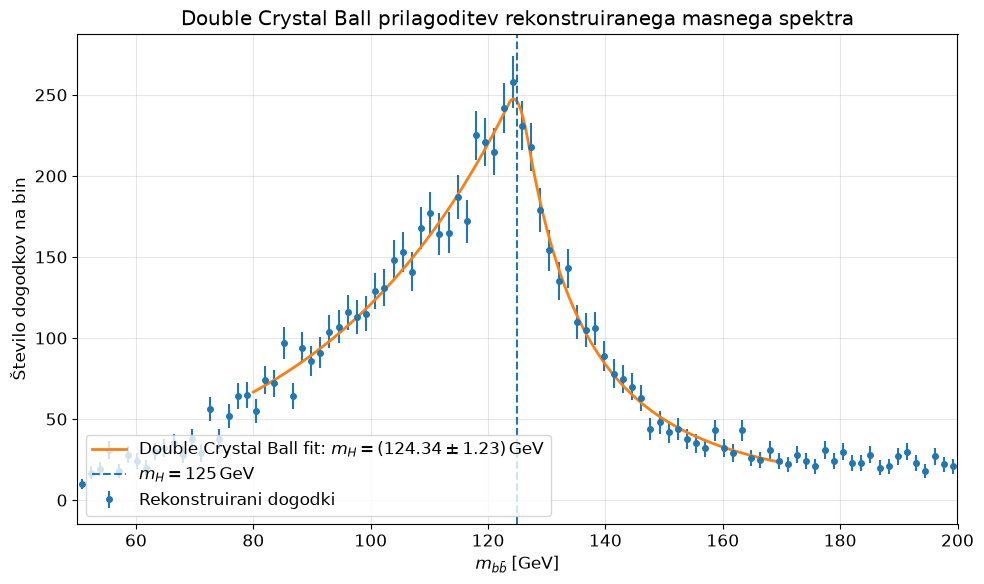

In [135]:
mass_plot = np.linspace(
    fit_min,
    fit_max,
    1000
)

fit_curve_cb = CrystalBall(
    mass_plot,
    *optimal_parameters_cb
)

plt.figure(figsize=(10, 6))

plt.errorbar(
    bin_centers,
    hist_counts,
    yerr=np.sqrt(
        np.maximum(hist_counts, 1)
    ),
    fmt="o",
    markersize=4,
    label="Rekonstruirani dogodki"
)

plt.plot(
    mass_plot,
    fit_curve_cb,
    linewidth=2,
    label=(
        rf"Double Crystal Ball fit: "
        rf"$m_H=({mCB_cb:.2f}"
        rf"\pm{mCB_err:.2f})\,\mathrm{{GeV}}$"
    )
)

plt.axvline(
    125,
    linestyle="--",
    linewidth=1.5,
    label=r"$m_H=125\,\mathrm{GeV}$"
)

plt.xlim(50, 200)

plt.xlabel(
    r"$m_{b\bar b}\;[\mathrm{GeV}]$"
)

plt.ylabel("Število dogodkov na bin")

plt.title(
    "Double Crystal Ball prilagoditev "
    "rekonstruiranega masnega spektra"
)

plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()